In [2]:
import tensorflow as tf
print(tf.__version__)

import numpy as np
import pandas as pd

# from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from util import *


from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


from sklearn.model_selection import StratifiedKFold

from imblearn.over_sampling import RandomOverSampler

import matplotlib.pyplot as plt
from visualisation import plot_cm
import joblib




2.4.1
2.4.1


2025-06-30 10:03:52.575356: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2025-06-30 10:03:52.576026: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2025-06-30 10:03:52.582847: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:941] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-06-30 10:03:52.583070: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:08:00.0 name: NVIDIA GeForce RTX 3070 computeCapability: 8.6
coreClock: 1.77GHz coreCount: 46 deviceMemorySize: 7.79GiB deviceMemoryBandwidth: 417.29GiB/s
2025-06-30 10:03:52.583081: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1
2025-06-30 10:03:52.584407: I tensorflow/stream_executor/platform/def

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 16456907215637215907
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 59244544
locality {
  bus_id: 1
  links {
  }
}
incarnation: 5060161214020478905
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:08:00.0, compute capability: 8.6"
]
Num GPUs Available:  1


In [3]:
SEED = 41

# Load Data

In [ ]:
df = pd.read_csv("../../data/training_data.csv")

# Prep Data

In [5]:
train_df, test_df = train_test_split(df, test_size=0.2,stratify=df['type'],random_state=SEED) #

train_labels = np.array(train_df.pop('type'))
test_labels = np.array(test_df.pop('type'))



train_features = np.array(train_df[['-logP_Struc','-logP_Contact',"area_sc",'per_con','per_no_con','contact_order']])
test_features = np.array(test_df[['-logP_Struc','-logP_Contact',"area_sc",'per_con','per_no_con','contact_order']])


In [7]:
# scaler = RobustScaler()
scaler = joblib.load("./scaler.pkl")
train_features = scaler.transform(train_features)
test_features = scaler.transform(test_features)

## Cross Validation

In [8]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from joblib import dump, load

In [9]:
X,y = train_features, train_labels

In [ ]:
# fix random seed for reproducibility
seed = SEED
np.random.seed(seed)


HISTORY_LIST = []

save_dir = './saved_models/'
fold_num = 1


BATCH_SIZE=1024
EPOCHS=200

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


for train_ix, val_ix in kfold.split(X, y):
    
    print(f"\n################################# Fold Number {fold_num}#################################")
   

    train_X, val_X = X[train_ix], X[val_ix]
    train_y, val_y = y[train_ix], y[val_ix]
    
    ros = RandomOverSampler(random_state=SEED)
    X_train_resampled, y_train_resampled = ros.fit_resample(train_X, train_y)
    
    model = RandomForestClassifier(random_state=seed)
    # model = svm.SVC(random_state=SEED)
    # model = LogisticRegression(random_state=seed)    
    

    val_ds = tf.data.Dataset.from_tensor_slices((val_X, val_y)).cache()
    resampled_ds = tf.data.Dataset.from_tensor_slices((X_train_resampled,y_train_resampled))

    history = model.fit(X_train_resampled, y_train_resampled)
   
    dump(history, "./saved_models/model_RandomForest_"+str(fold_num)+".joblib")
    
    HISTORY_LIST.append(history)

    tf.keras.backend.clear_session()

    fold_num += 1



################################# Fold Number 1#################################

################################# Fold Number 2#################################

################################# Fold Number 3#################################

################################# Fold Number 4#################################

################################# Fold Number 5#################################


/home/iwe18/Documents/joh/PhD/projects/EvoDenovo/Supplements/visualisation.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels(np.arange(0,1751,250), fontsize=30, fontname='Arial', weight='bold', color=my_col)


[[1526   12]
 [  18   28]]


/home/iwe18/Documents/joh/PhD/projects/EvoDenovo/Supplements/visualisation.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels(np.arange(0,1751,250), fontsize=30, fontname='Arial', weight='bold', color=my_col)


[[1526   12]
 [  19   27]]


/home/iwe18/Documents/joh/PhD/projects/EvoDenovo/Supplements/visualisation.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels(np.arange(0,1751,250), fontsize=30, fontname='Arial', weight='bold', color=my_col)


[[1526   12]
 [  19   27]]


/home/iwe18/Documents/joh/PhD/projects/EvoDenovo/Supplements/visualisation.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels(np.arange(0,1751,250), fontsize=30, fontname='Arial', weight='bold', color=my_col)


[[1526   12]
 [  19   27]]


/home/iwe18/Documents/joh/PhD/projects/EvoDenovo/Supplements/visualisation.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels(np.arange(0,1751,250), fontsize=30, fontname='Arial', weight='bold', color=my_col)


[[1524   14]
 [  19   27]]


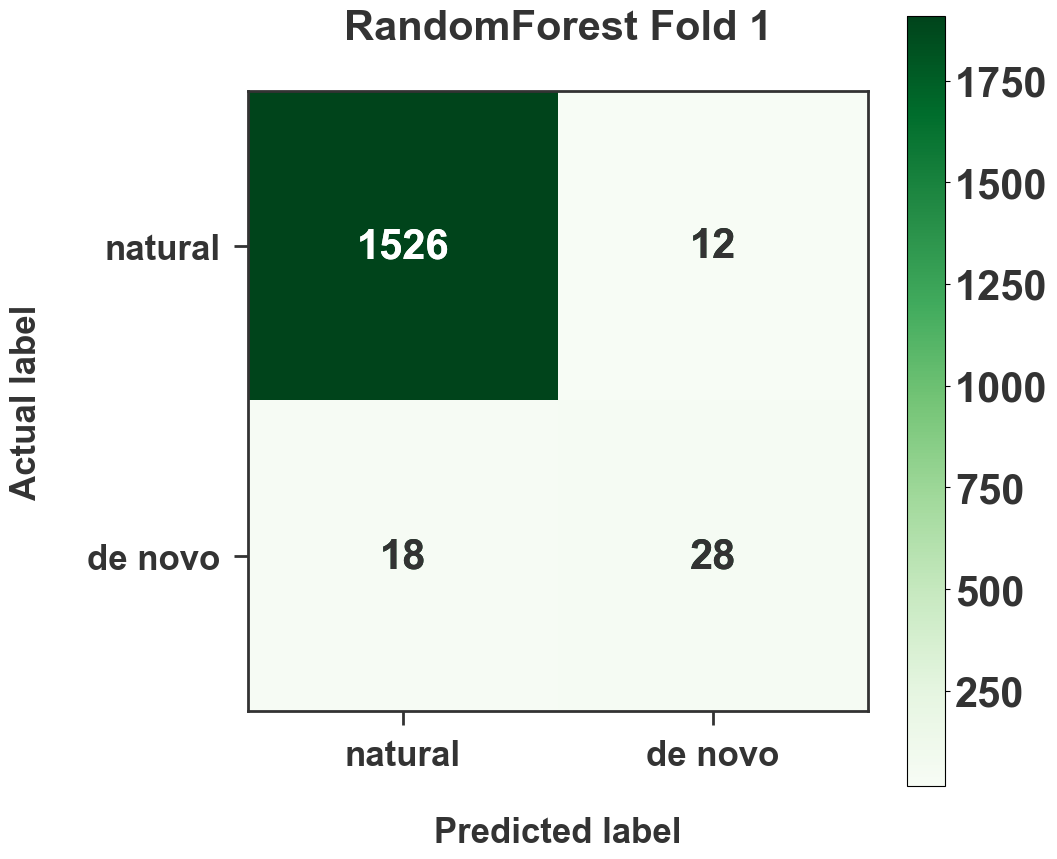

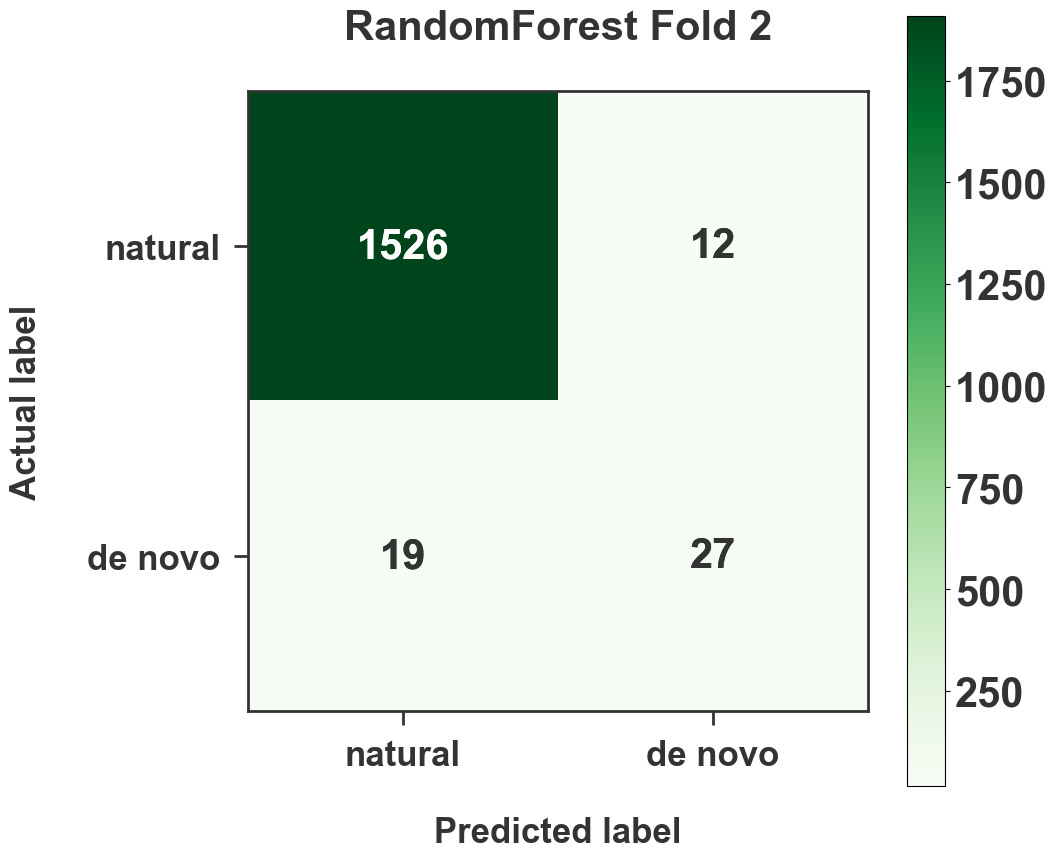

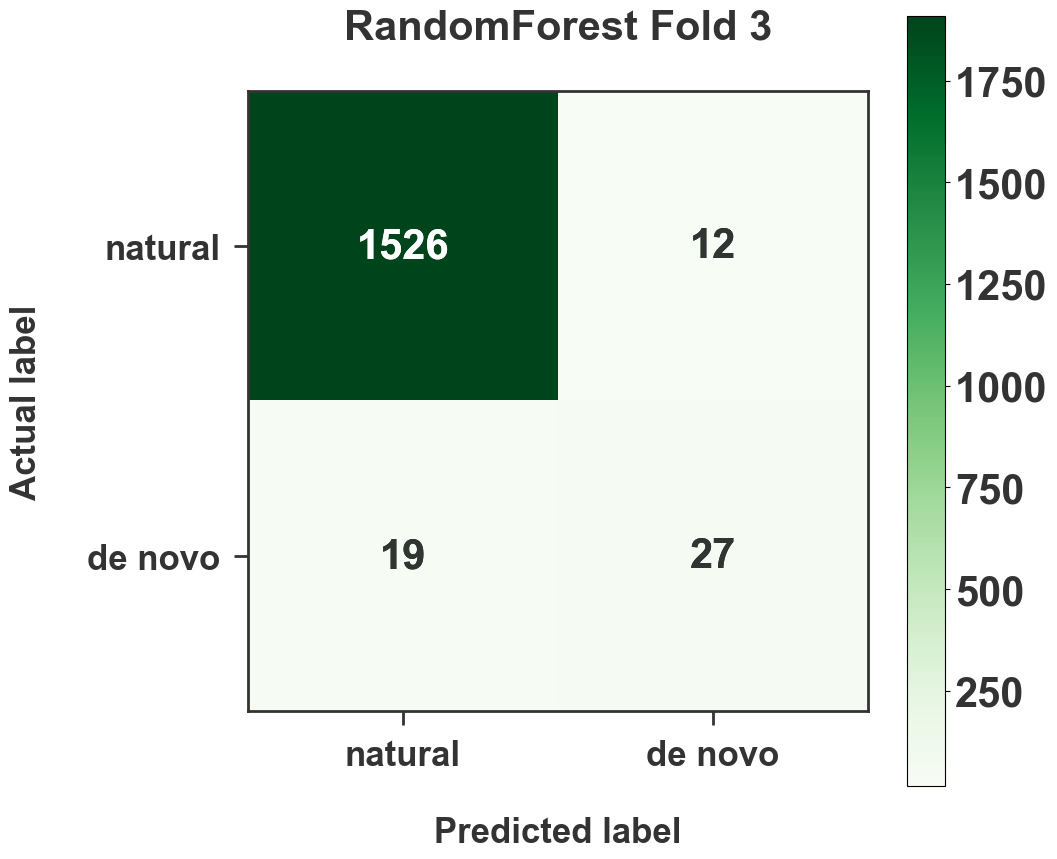

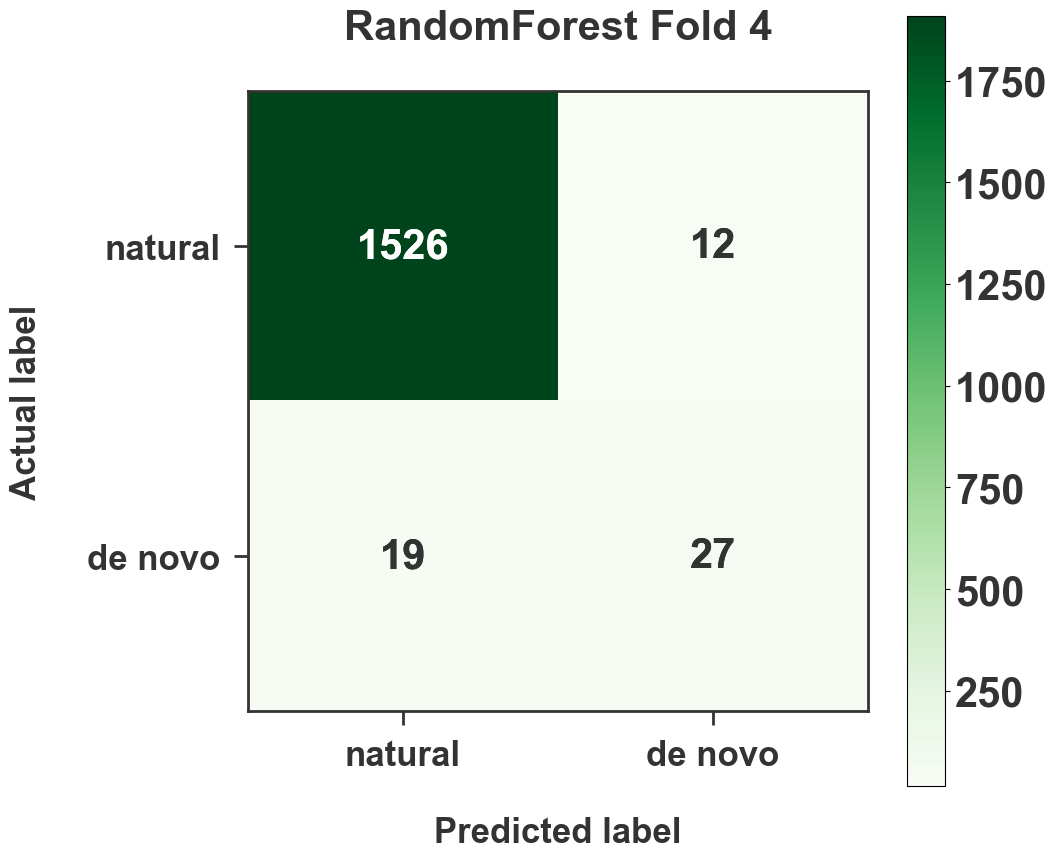

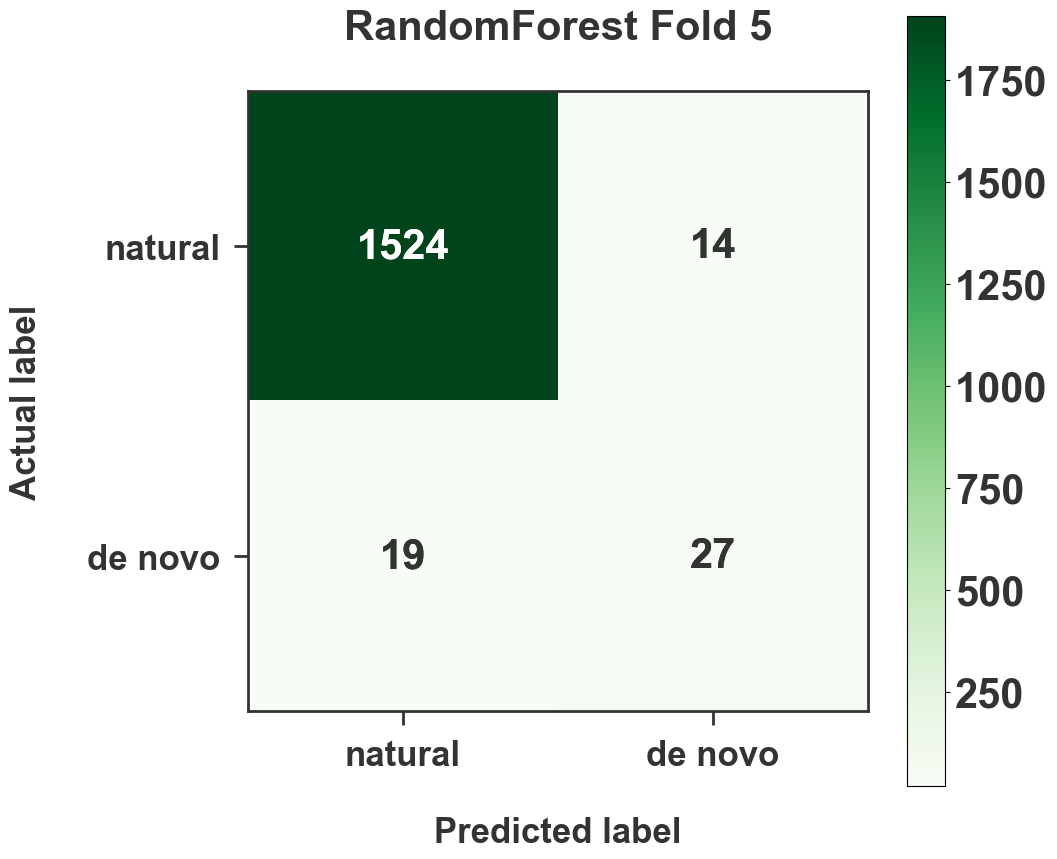

In [ ]:
color = plt.cm.Greens

for i in range(1,fold_num):
    my_model = load("./saved_models/model_RandomForest_"+str(i)+".joblib")
    test_predictions = my_model.predict(test_features)
    plot_cm(test_labels, test_predictions,color,title=f"RandomForest Fold {i}\n",ylabel="Actual label\n",xlabel="\nPredicted label")
    plt.savefig("./cm/cm_RandomForest_"+str(i),dpi=300,bbox_inches='tight')

In [ ]:
# fix random seed for reproducibility
seed = SEED
np.random.seed(seed)


HISTORY_LIST = []

save_dir = './saved_models/'
fold_num = 1


BATCH_SIZE=1024
EPOCHS=200

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


for train_ix, val_ix in kfold.split(X, y):
    
    print(f"\n################################# Fold Number {fold_num}#################################")
   

    train_X, val_X = X[train_ix], X[val_ix]
    train_y, val_y = y[train_ix], y[val_ix]
    
    ros = RandomOverSampler(random_state=SEED)
    X_train_resampled, y_train_resampled = ros.fit_resample(train_X, train_y)
    
    # model = RandomForestClassifier(random_state=seed)
    model = svm.SVC(random_state=SEED)
    # model = LogisticRegression(random_state=seed)    
    

    val_ds = tf.data.Dataset.from_tensor_slices((val_X, val_y)).cache()
    resampled_ds = tf.data.Dataset.from_tensor_slices((X_train_resampled,y_train_resampled))

    history = model.fit(X_train_resampled, y_train_resampled)
   
    dump(history, "./saved_models/model_svm_"+str(fold_num)+".joblib")
    
    HISTORY_LIST.append(history)

    tf.keras.backend.clear_session()

    fold_num += 1


################################# Fold Number 1#################################

################################# Fold Number 2#################################

################################# Fold Number 3#################################

################################# Fold Number 4#################################

################################# Fold Number 5#################################


/home/iwe18/Documents/joh/PhD/projects/EvoDenovo/Supplements/visualisation.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels(np.arange(0,1751,250), fontsize=30, fontname='Arial', weight='bold', color=my_col)


[[1437  101]
 [   8   38]]


/home/iwe18/Documents/joh/PhD/projects/EvoDenovo/Supplements/visualisation.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels(np.arange(0,1751,250), fontsize=30, fontname='Arial', weight='bold', color=my_col)


[[1443   95]
 [   7   39]]


/home/iwe18/Documents/joh/PhD/projects/EvoDenovo/Supplements/visualisation.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels(np.arange(0,1751,250), fontsize=30, fontname='Arial', weight='bold', color=my_col)


[[1449   89]
 [   8   38]]


/home/iwe18/Documents/joh/PhD/projects/EvoDenovo/Supplements/visualisation.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels(np.arange(0,1751,250), fontsize=30, fontname='Arial', weight='bold', color=my_col)


[[1452   86]
 [   7   39]]


/home/iwe18/Documents/joh/PhD/projects/EvoDenovo/Supplements/visualisation.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels(np.arange(0,1751,250), fontsize=30, fontname='Arial', weight='bold', color=my_col)


[[1439   99]
 [   7   39]]


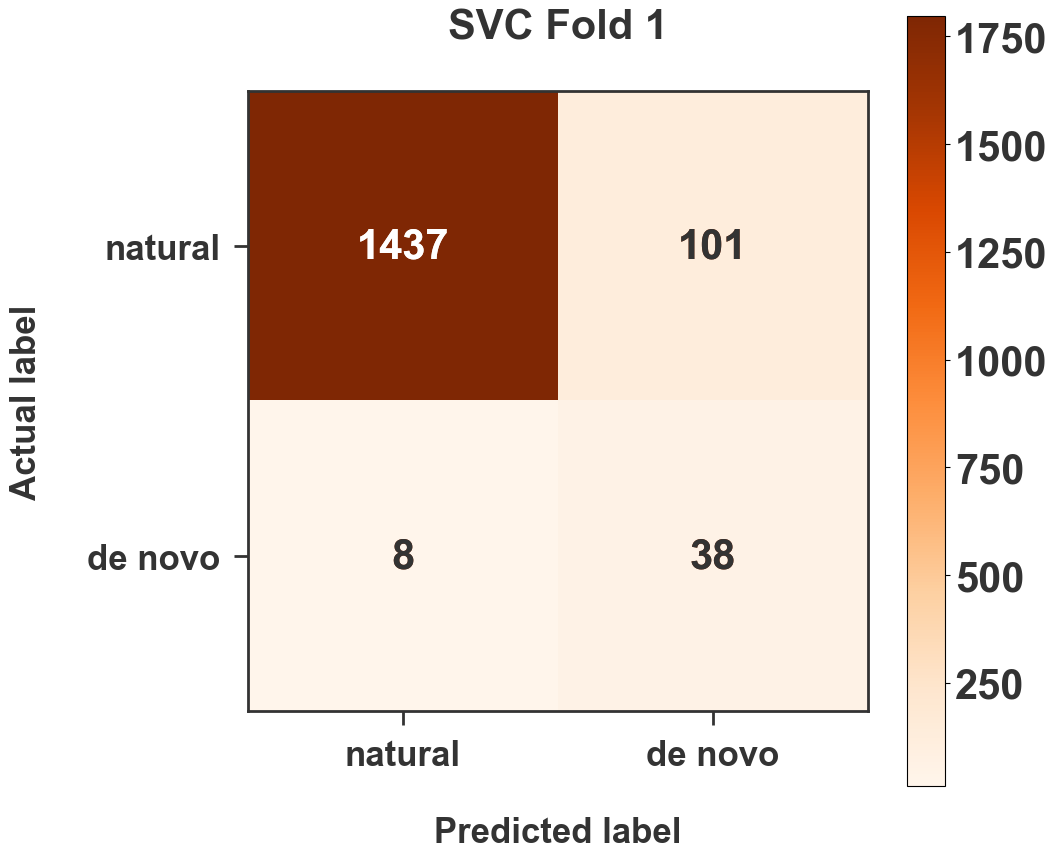

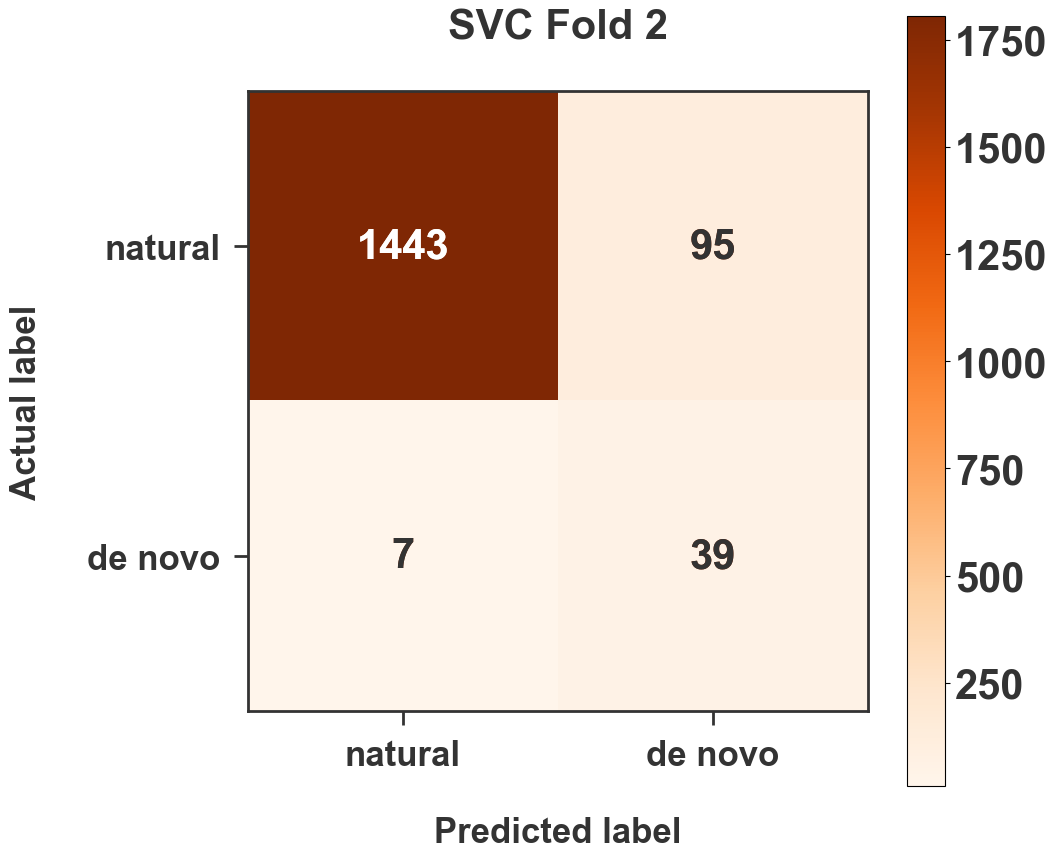

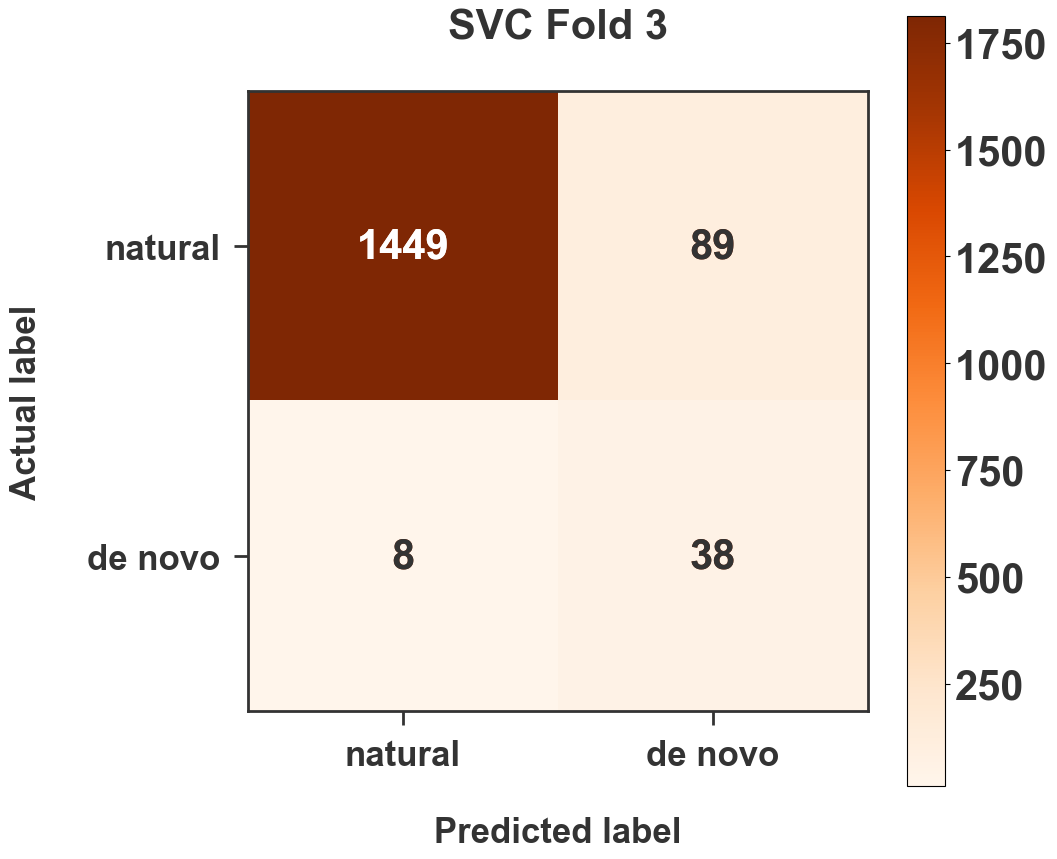

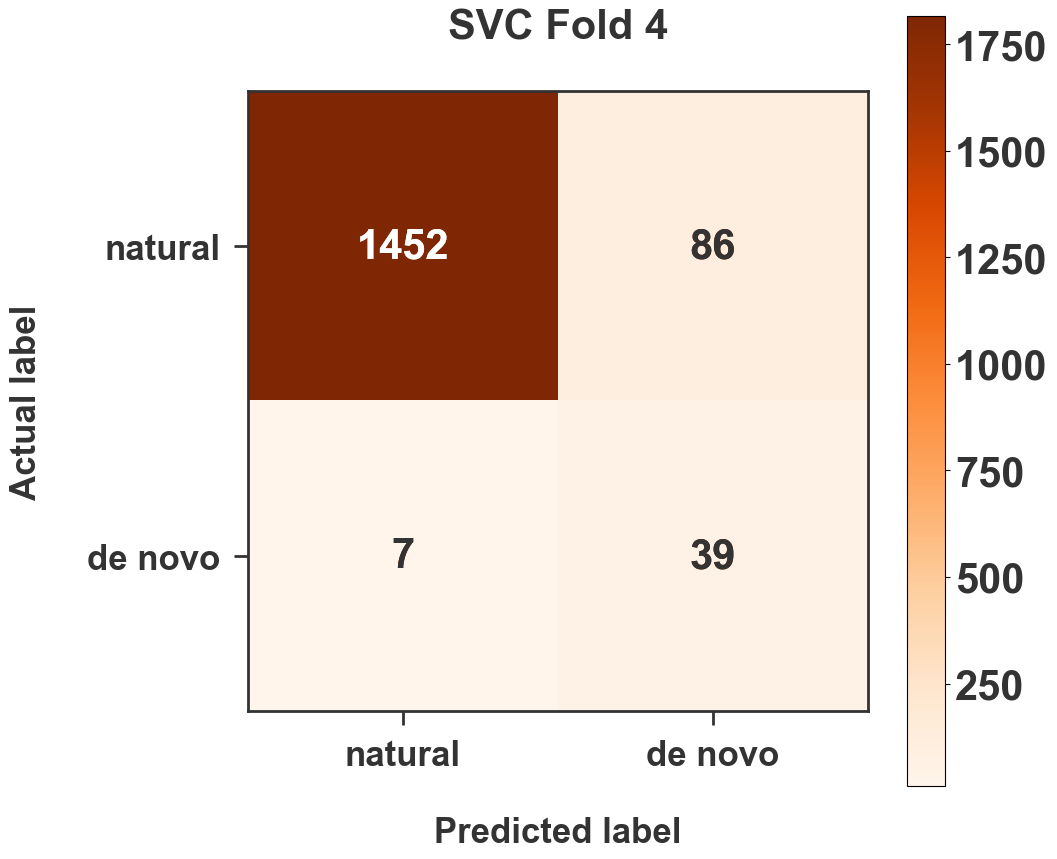

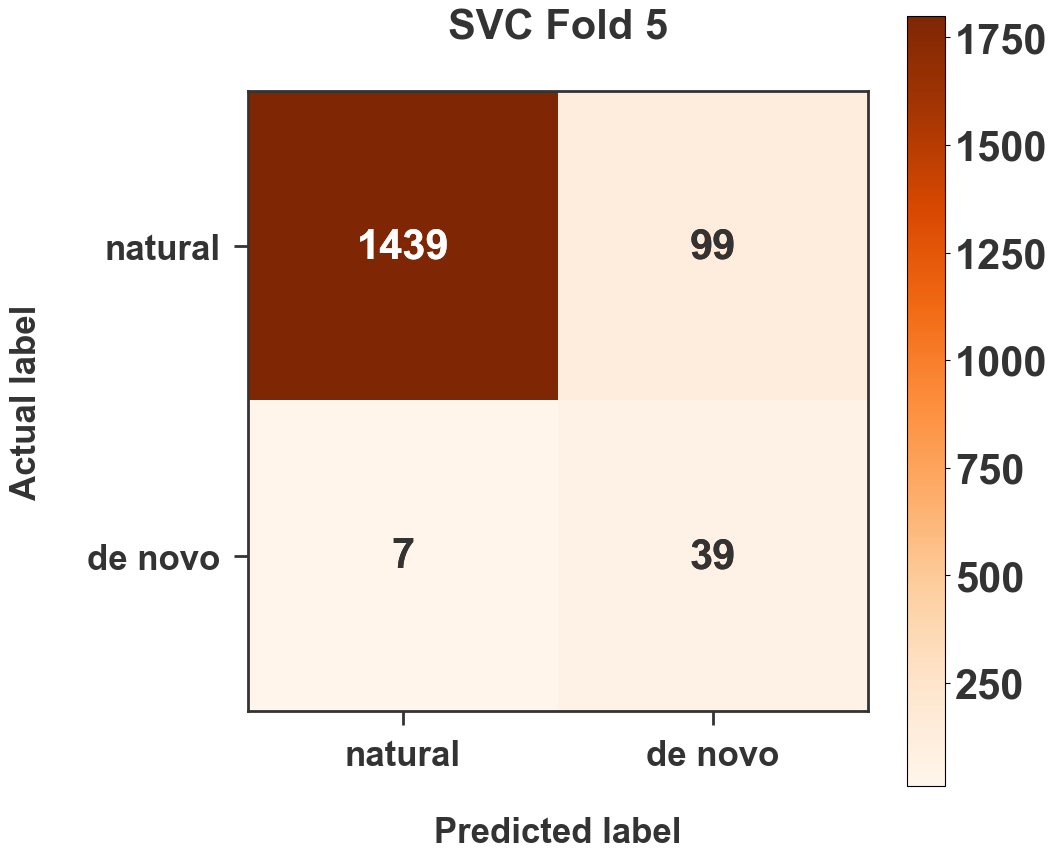

In [ ]:
color = plt.cm.Oranges

for i in range(1,fold_num):
    my_model = load("./saved_models/model_svm_"+str(i)+".joblib")
    test_predictions = my_model.predict(test_features)
    plot_cm(test_labels, test_predictions,color,title=f"SVC Fold {i}\n",ylabel="Actual label\n",xlabel="\nPredicted label")
    plt.savefig("./cm/cm_svm_"+str(i),dpi=300,bbox_inches='tight')

In [ ]:
# fix random seed for reproducibility
seed = SEED
np.random.seed(seed)


HISTORY_LIST = []

save_dir = './saved_models/'
fold_num = 1


BATCH_SIZE=1024
EPOCHS=200

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


for train_ix, val_ix in kfold.split(X, y):
    
    print(f"\n################################# Fold Number {fold_num}#################################")
   

    train_X, val_X = X[train_ix], X[val_ix]
    train_y, val_y = y[train_ix], y[val_ix]
    
    ros = RandomOverSampler(random_state=SEED)
    X_train_resampled, y_train_resampled = ros.fit_resample(train_X, train_y)
    
    # model = RandomForestClassifier(random_state=seed)
    # model = svm.SVC(random_state=SEED)
    model = LogisticRegression(random_state=seed)    
    

    val_ds = tf.data.Dataset.from_tensor_slices((val_X, val_y)).cache()
    resampled_ds = tf.data.Dataset.from_tensor_slices((X_train_resampled,y_train_resampled))

    history = model.fit(X_train_resampled, y_train_resampled)
   
    dump(history, "./saved_models/model_LogisticRegression_"+str(fold_num)+".joblib")
    
    HISTORY_LIST.append(history)

    tf.keras.backend.clear_session()

    fold_num += 1



################################# Fold Number 1#################################

################################# Fold Number 2#################################

################################# Fold Number 3#################################

################################# Fold Number 4#################################

################################# Fold Number 5#################################


/home/iwe18/Documents/joh/PhD/projects/EvoDenovo/Supplements/visualisation.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels(np.arange(0,1751,250), fontsize=30, fontname='Arial', weight='bold', color=my_col)


[[1364  174]
 [   6   40]]


/home/iwe18/Documents/joh/PhD/projects/EvoDenovo/Supplements/visualisation.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels(np.arange(0,1751,250), fontsize=30, fontname='Arial', weight='bold', color=my_col)


[[1366  172]
 [   5   41]]


/home/iwe18/Documents/joh/PhD/projects/EvoDenovo/Supplements/visualisation.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels(np.arange(0,1751,250), fontsize=30, fontname='Arial', weight='bold', color=my_col)


[[1374  164]
 [   5   41]]


/home/iwe18/Documents/joh/PhD/projects/EvoDenovo/Supplements/visualisation.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels(np.arange(0,1751,250), fontsize=30, fontname='Arial', weight='bold', color=my_col)


[[1390  148]
 [   6   40]]


/home/iwe18/Documents/joh/PhD/projects/EvoDenovo/Supplements/visualisation.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels(np.arange(0,1751,250), fontsize=30, fontname='Arial', weight='bold', color=my_col)


[[1361  177]
 [   6   40]]


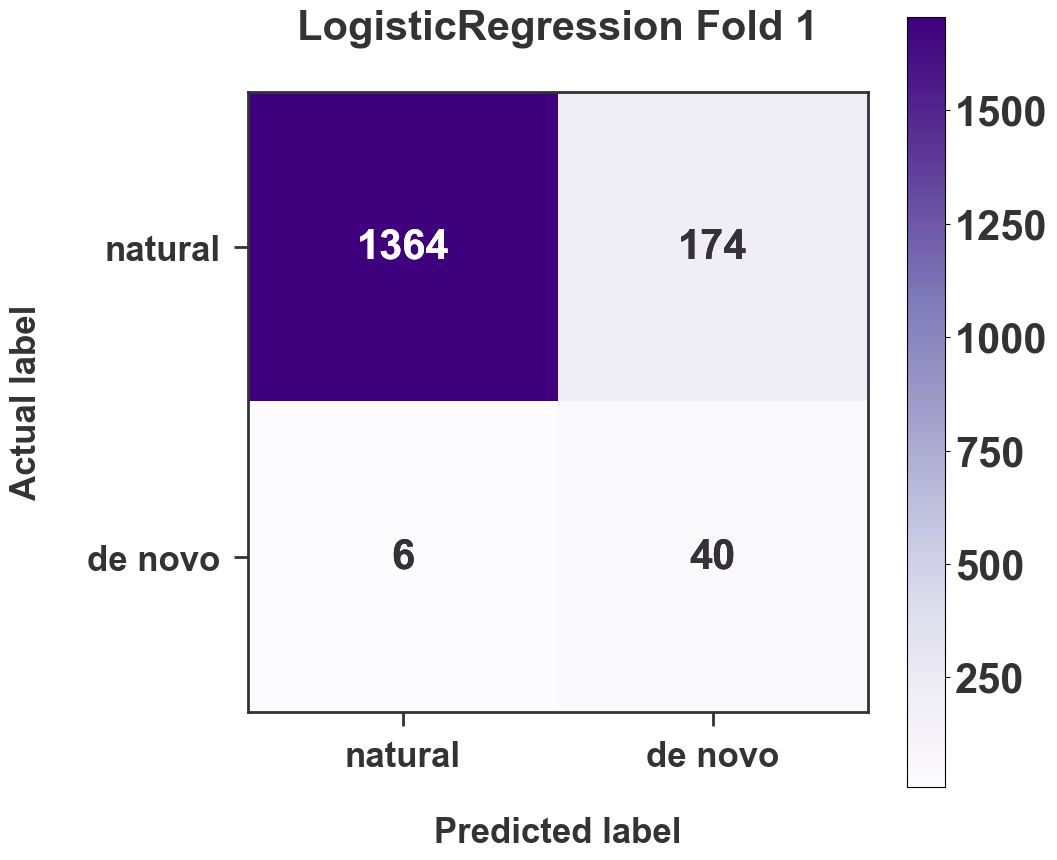

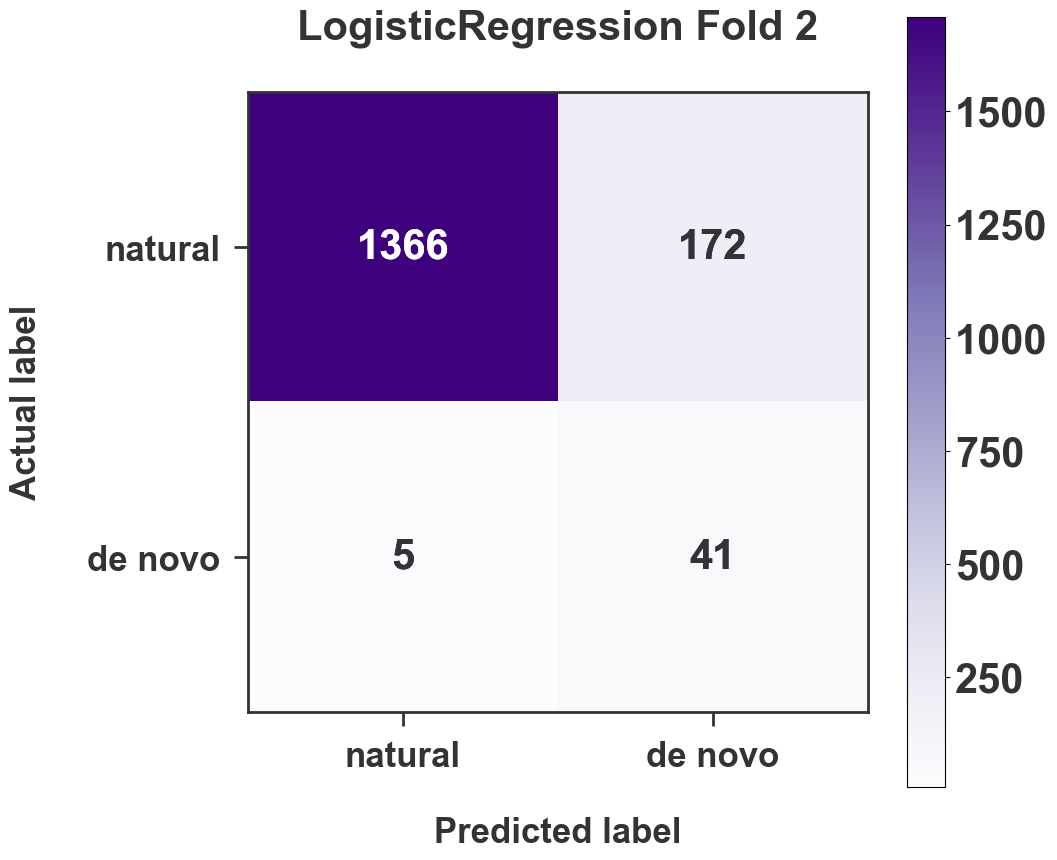

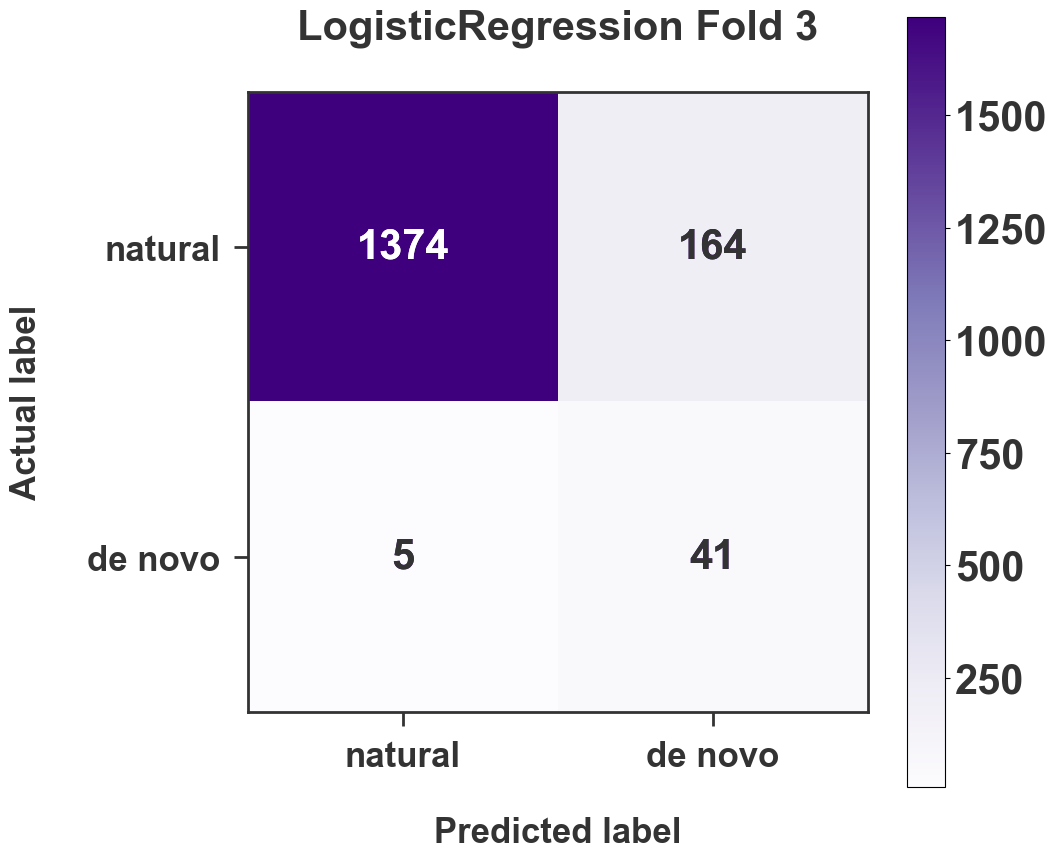

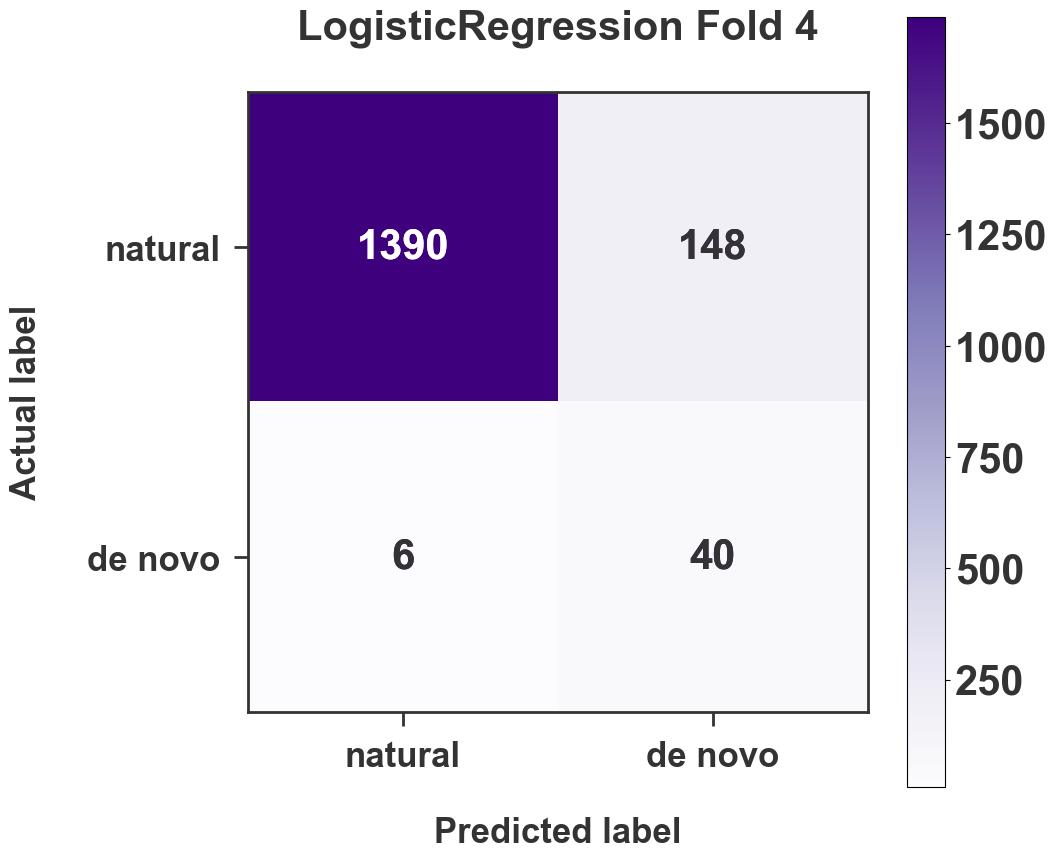

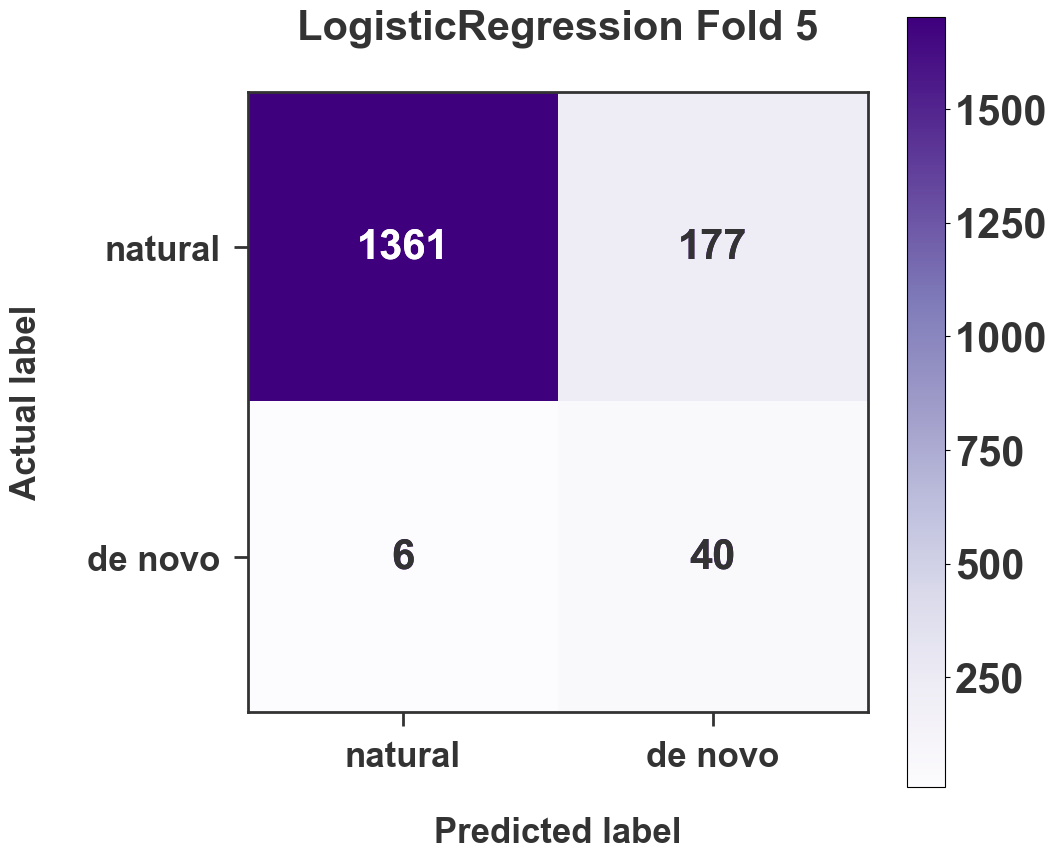

In [ ]:
color = plt.cm.Purples

for i in range(1,fold_num):
    my_model = load("./saved_models/model_LogisticRegression_"+str(i)+".joblib")
    test_predictions = my_model.predict(test_features)
    plot_cm(test_labels, test_predictions,color,title=f"LogisticRegression Fold {i}\n",ylabel="Actual label\n",xlabel="\nPredicted label")
    plt.savefig("./cm/cm_LogisticRegression_"+str(i),dpi=300,bbox_inches='tight')